# Etapa 1 — Análise Exploratória dos Dados (EDA)

**Objetivo:** Entender o que o 3W Dataset tem antes de fazer qualquer processamento.

Antes de treinar qualquer modelo, precisamos responder:
- Quantas instâncias existem por tipo de falha?
- Quais sensores têm mais dados faltantes?
- Como são os padrões visuais de cada falha?
- As classes estão balanceadas?

Pense nisso como o "reconhecimento de terreno" antes de começar a construção.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt

from config import FAULT_CLASSES, KEY_SENSORS
from src.data_loader import count_instances, load_sample
from src.visualization import (
    plot_class_distribution,
    plot_correlation_heatmap,
    plot_missing_data,
    plot_time_series,
)

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


## 1.1 Contagem de instâncias por classe

Cada 'instância' é um arquivo Parquet = uma gravação contínua de um poço durante um evento.
Contar sem carregar os dados é rápido — basta listar os arquivos.

In [2]:
counts = count_instances()
print('\nInstâncias por classe e tipo de fonte:')
print(counts.to_string())


Instâncias por classe e tipo de fonte:
                               fault_label  total  WELL  SIMULATED  DRAWN
fault_class                                                              
0                                   Normal    594   594          0      0
1                   Aumento Abrupto de BSW    128     4        114     10
2               Fechamento Espúrio da DHSV     38    22         16      0
3                         Golfadas Severas    106    32         74      0
4                   Instabilidade de Fluxo    343   343          0      0
5            Perda Rápida de Produtividade    450    11        439      0
6                  Restrição Rápida no PCK    221     6        215      0
7                       Incrustação no PCK     46    36          0     10
8             Hidrato na Linha de Produção     95    14         81      0
9              Hidrato na Linha de Serviço    207    57        150      0


## 1.2 Carregar amostra para exploração

Carregamos 3 instâncias por classe — suficiente para visualizar padrões
sem precisar carregar os ~10 GB do dataset completo.

In [3]:
df_sample = load_sample(n_instances_per_class=3)

print(f'Shape da amostra: {df_sample.shape}')
print(f'Colunas: {list(df_sample.columns)}')
df_sample.head(3)

Shape da amostra: (2015200, 33)
Colunas: ['ABER-CKGL', 'ABER-CKP', 'ESTADO-DHSV', 'ESTADO-M1', 'ESTADO-M2', 'ESTADO-PXO', 'ESTADO-SDV-GL', 'ESTADO-SDV-P', 'ESTADO-W1', 'ESTADO-W2', 'ESTADO-XO', 'P-ANULAR', 'P-JUS-BS', 'P-JUS-CKGL', 'P-JUS-CKP', 'P-MON-CKGL', 'P-MON-CKP', 'P-MON-SDV-P', 'P-PDG', 'PT-P', 'P-TPT', 'QBS', 'QGL', 'T-JUS-CKP', 'T-MON-CKP', 'T-PDG', 'T-TPT', 'class', 'state', 'instance_id', 'fault_class', 'fault_label', 'source_type']


,ABER-CKGL,ABER-CKP,ESTADO-DHSV,ESTADO-M1,ESTADO-M2,ESTADO-PXO,ESTADO-SDV-GL,ESTADO-SDV-P,ESTADO-W1,ESTADO-W2,...,T-JUS-CKP,T-MON-CKP,T-PDG,T-TPT,class,state,instance_id,fault_class,fault_label,source_type
0,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,84.64463,NaN,0.0,119.0781,<NA>,<NA>,WELL-00001_20170201010207,0,Normal,WELL
1,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,84.63828,NaN,0.0,119.0781,<NA>,<NA>,WELL-00001_20170201010207,0,Normal,WELL
2,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,84.63194,NaN,0.0,119.0781,<NA>,<NA>,WELL-00001_20170201010207,0,Normal,WELL


## 1.3 Distribuição das classes

Figura salva: d:\Documentos\UnB\Projeto Final de Curso\TCC\notebooks\..\results\figures\distribuicao_classes.png


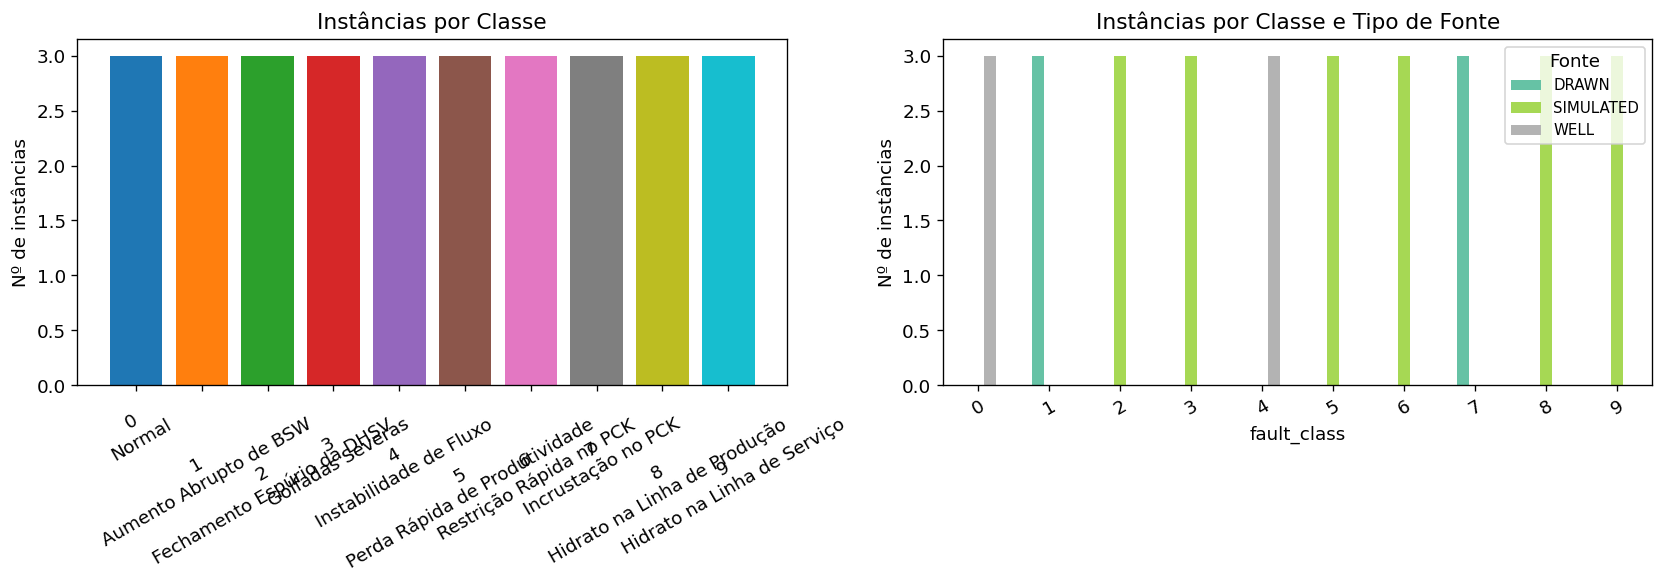

In [4]:
fig = plot_class_distribution(df_sample)
plt.show()

## 1.4 Dados faltantes por sensor e classe

No 3W, dados faltantes ocorrem por falha de sensor ou perda de comunicação.
O heatmap mostra a fração de NaN em cada combinação sensor × classe.
Células vermelhas escuras indicam sensores pouco confiáveis para aquela classe.

Figura salva: d:\Documentos\UnB\Projeto Final de Curso\TCC\notebooks\..\results\figures\dados_faltantes.png


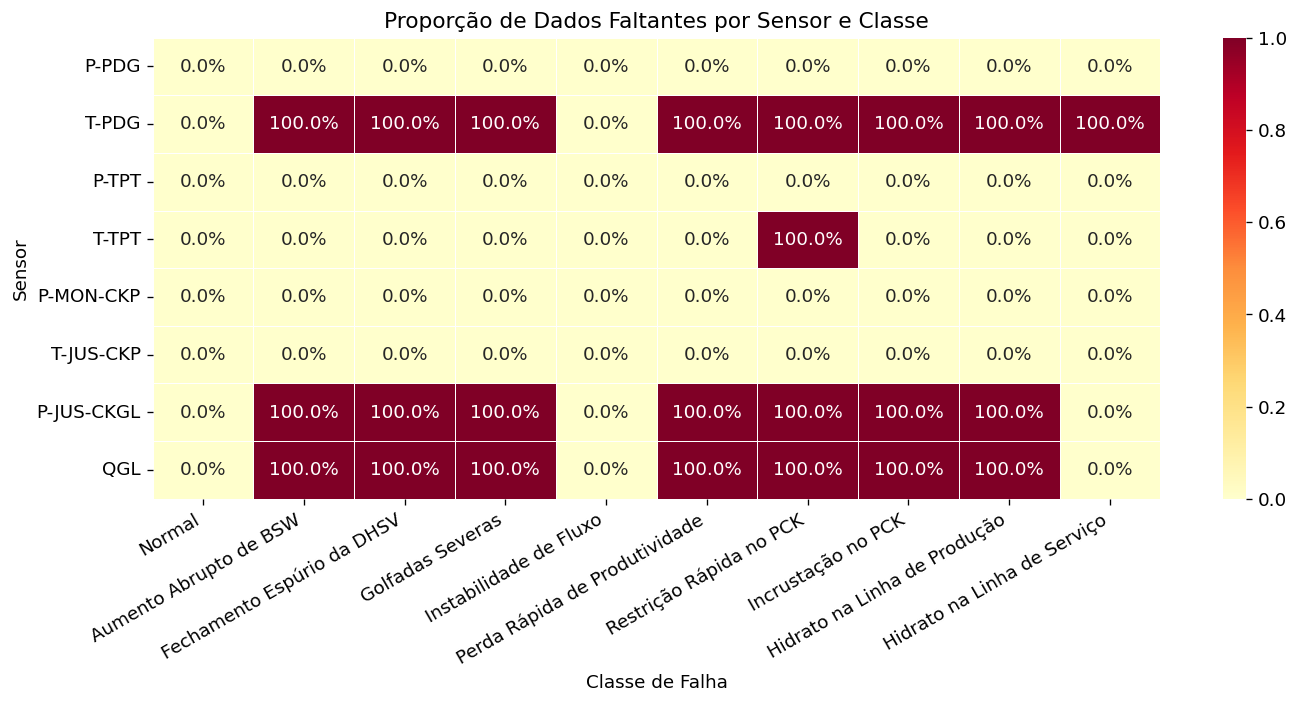

In [5]:
fig = plot_missing_data(df_sample)
plt.show()

## 1.5 Visualização das séries temporais por classe

Plotamos uma instância de cada tipo de falha para ver como os sensores se comportam.

O fundo colorido indica o estado operacional em cada instante:
- **Verde** → operação normal
- **Amarelo** → período transiente (sinal de que a falha está se aproximando)
- **Vermelho** → falha ativa

O título de cada gráfico mostra a classe de falha e o identificador da instância.

Figura salva: d:\Documentos\UnB\Projeto Final de Curso\TCC\notebooks\..\results\figures\serie_temporal_classe_0.png


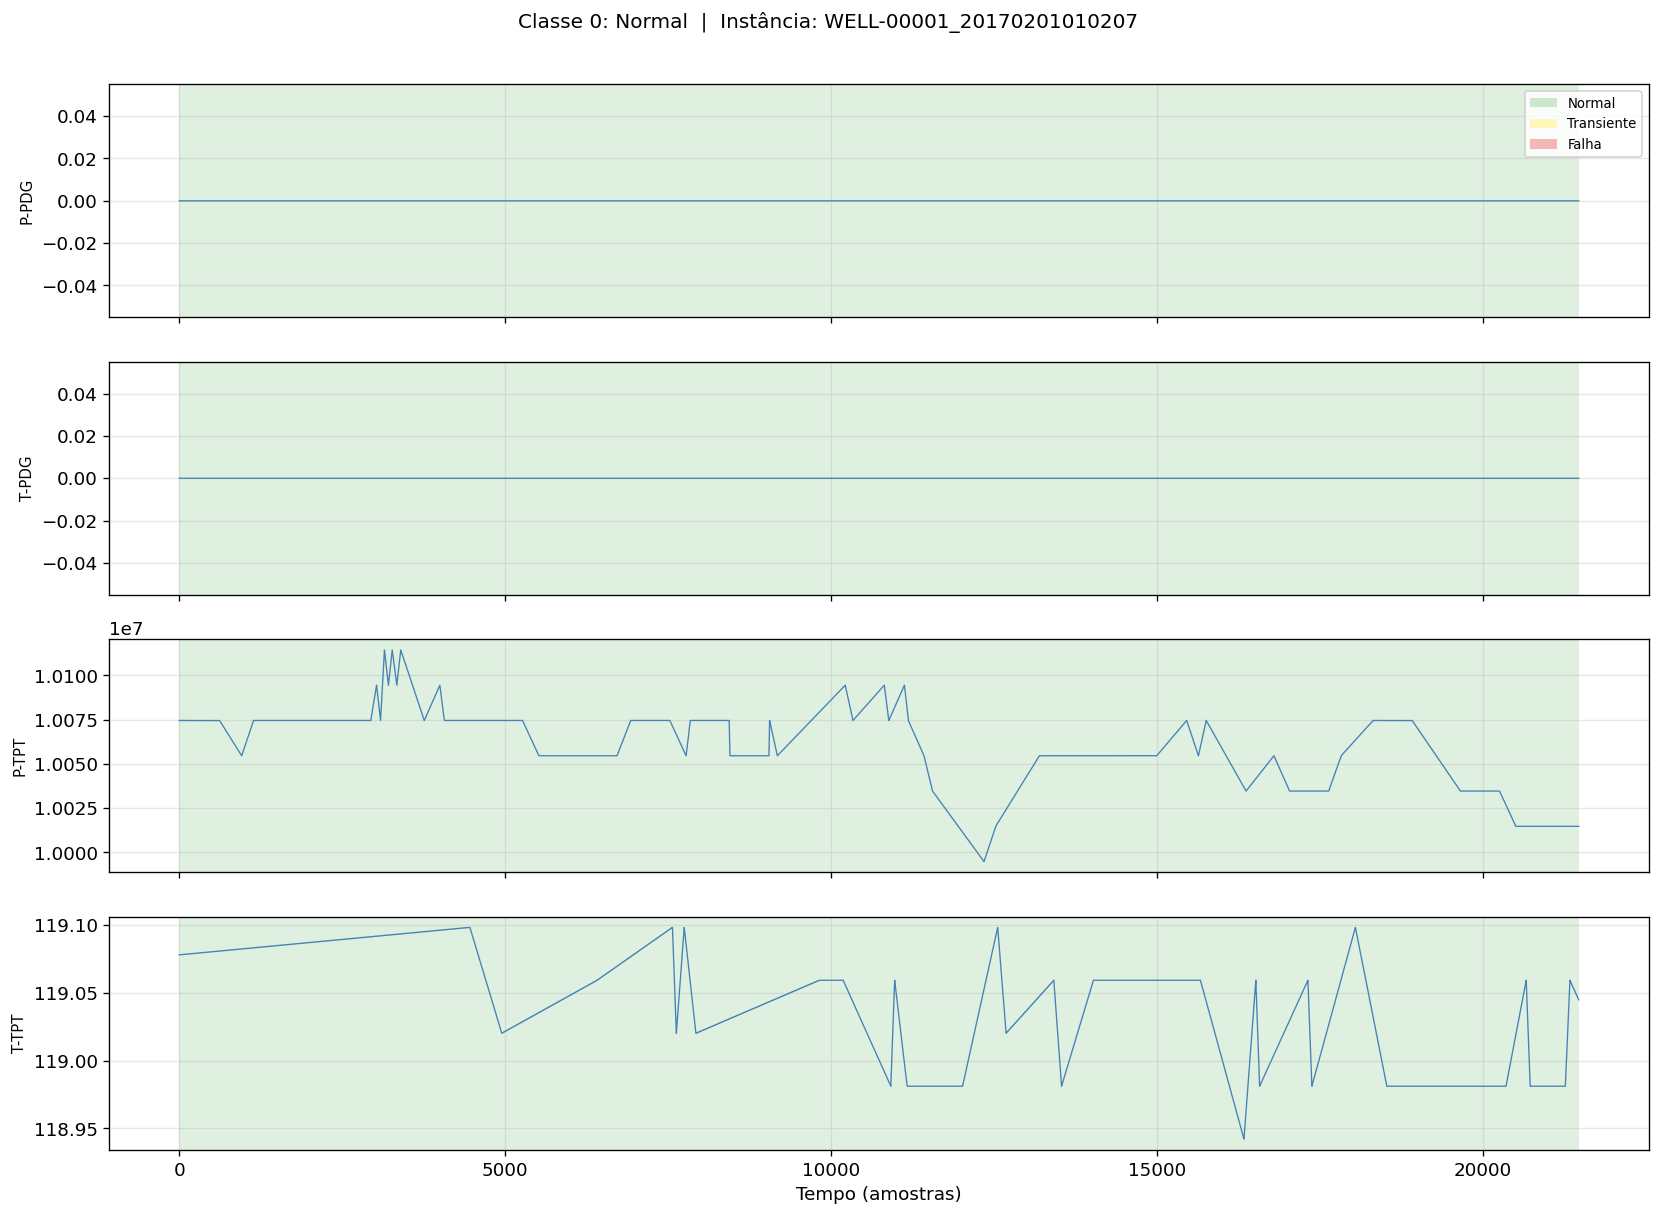

Figura salva: d:\Documentos\UnB\Projeto Final de Curso\TCC\notebooks\..\results\figures\serie_temporal_classe_1.png


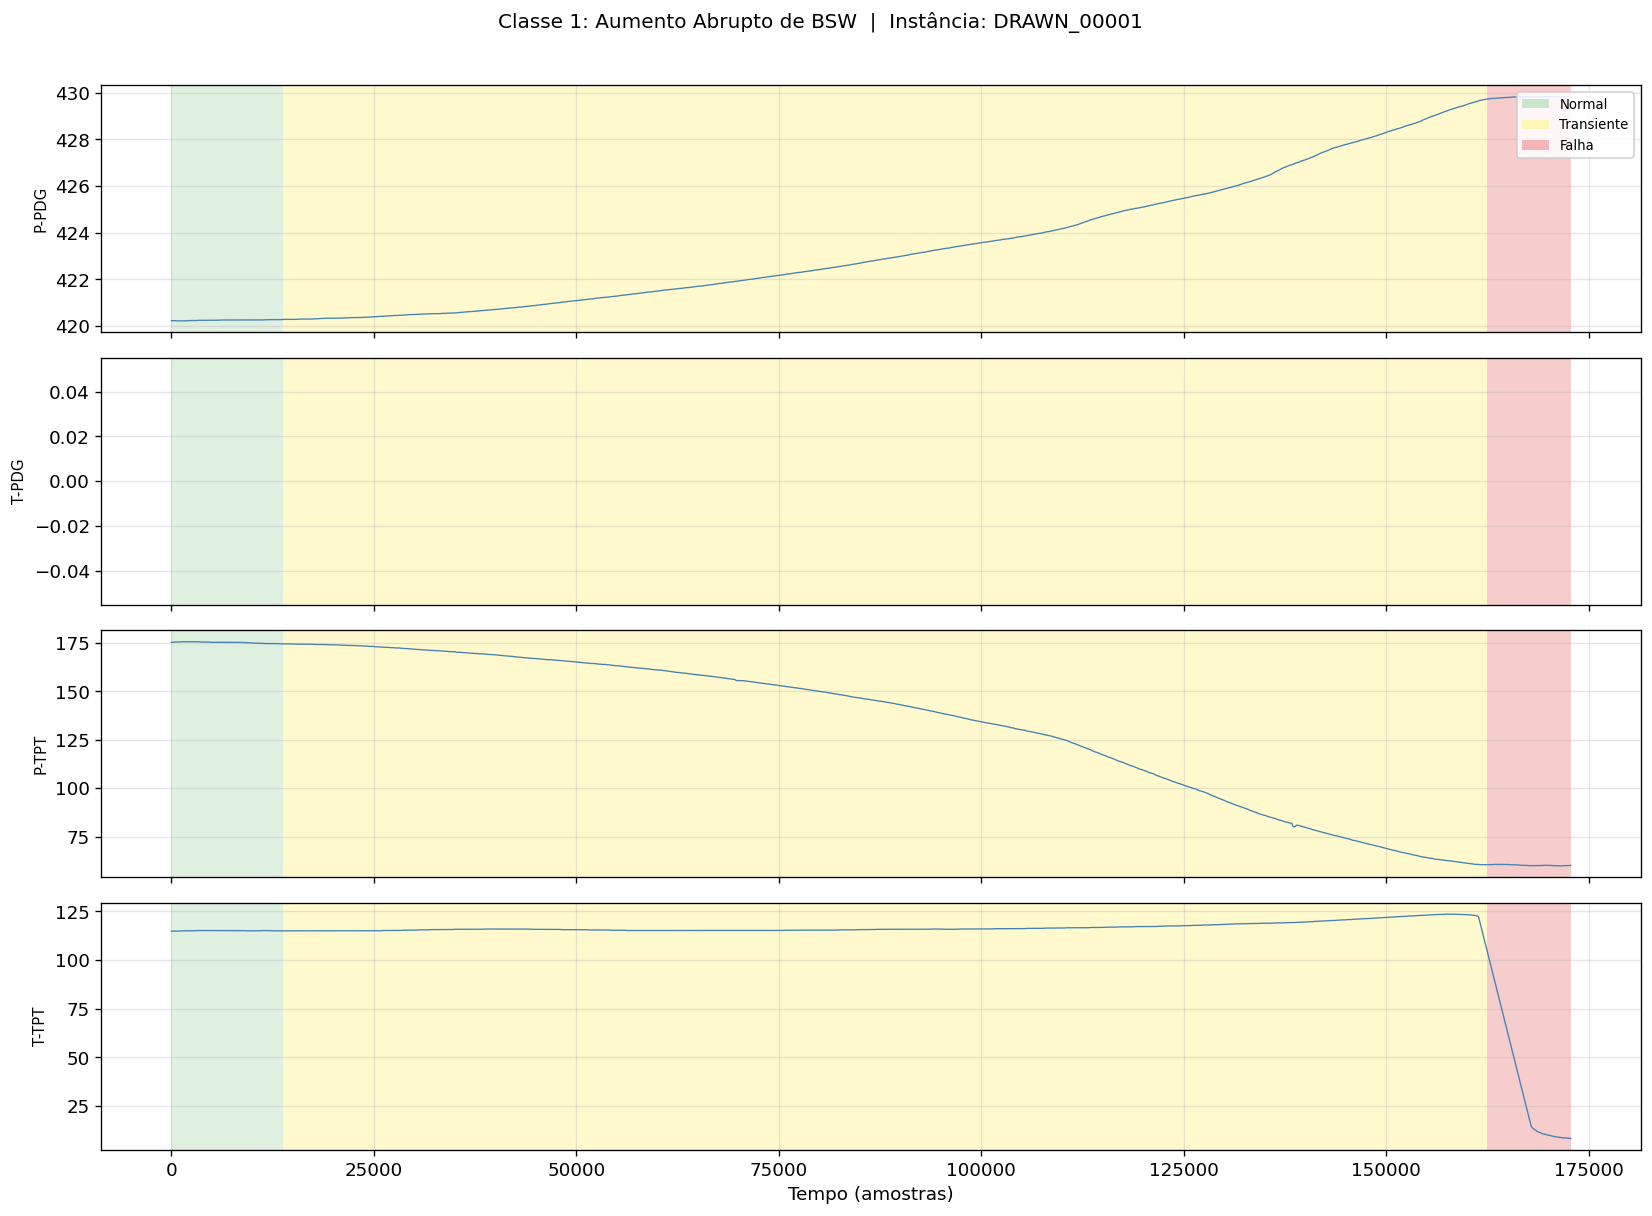

Figura salva: d:\Documentos\UnB\Projeto Final de Curso\TCC\notebooks\..\results\figures\serie_temporal_classe_2.png


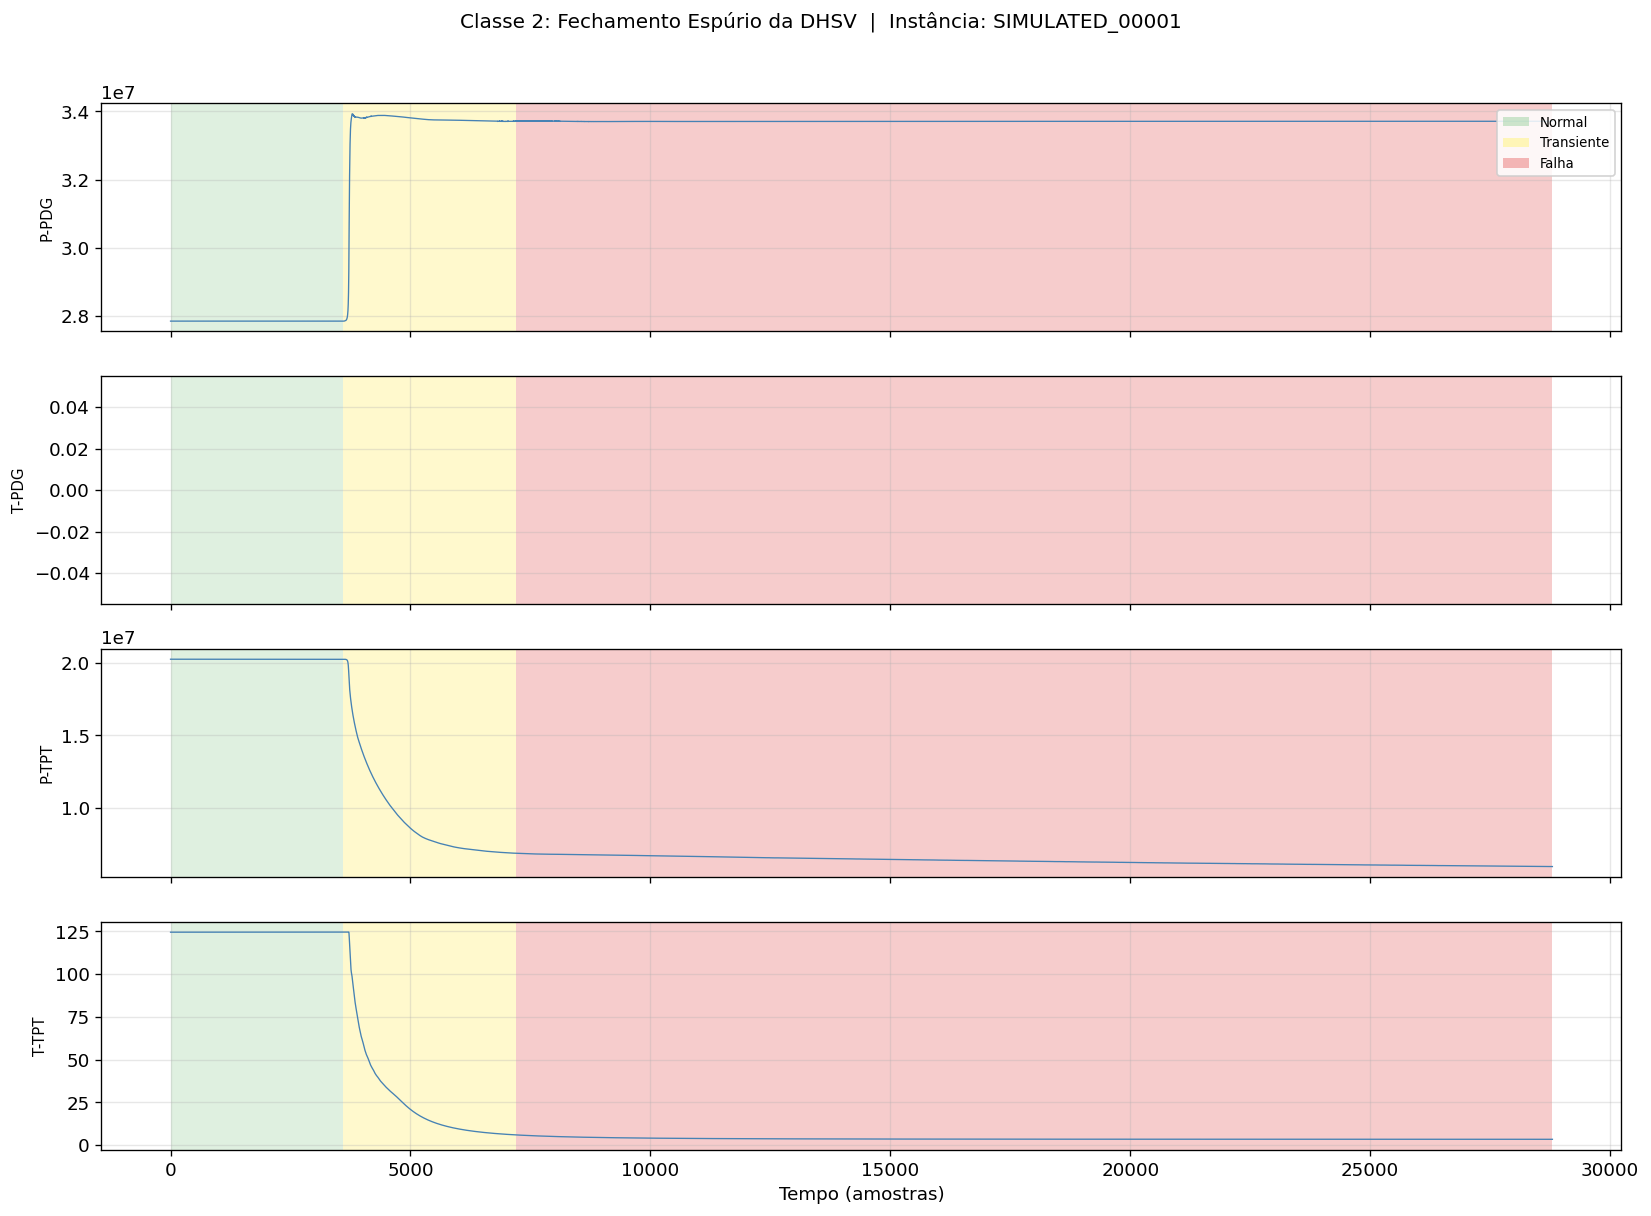

Figura salva: d:\Documentos\UnB\Projeto Final de Curso\TCC\notebooks\..\results\figures\serie_temporal_classe_3.png


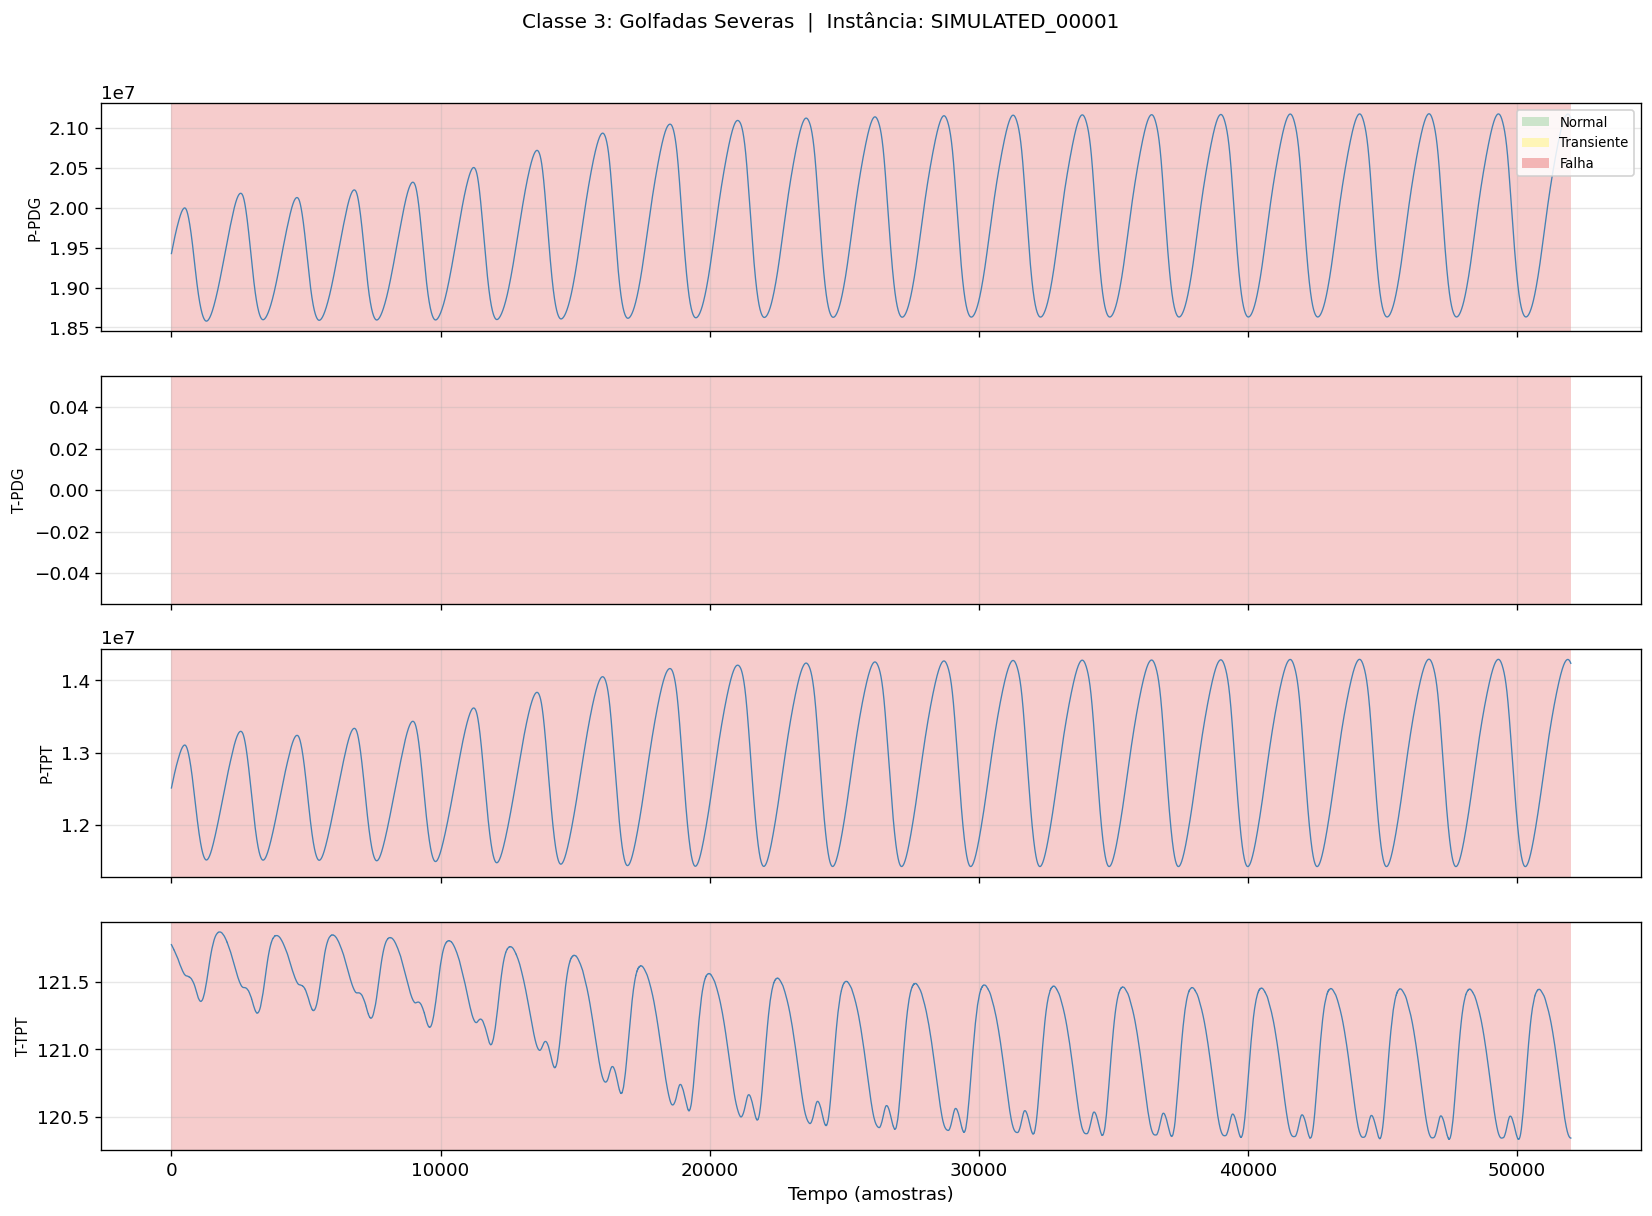

Figura salva: d:\Documentos\UnB\Projeto Final de Curso\TCC\notebooks\..\results\figures\serie_temporal_classe_4.png


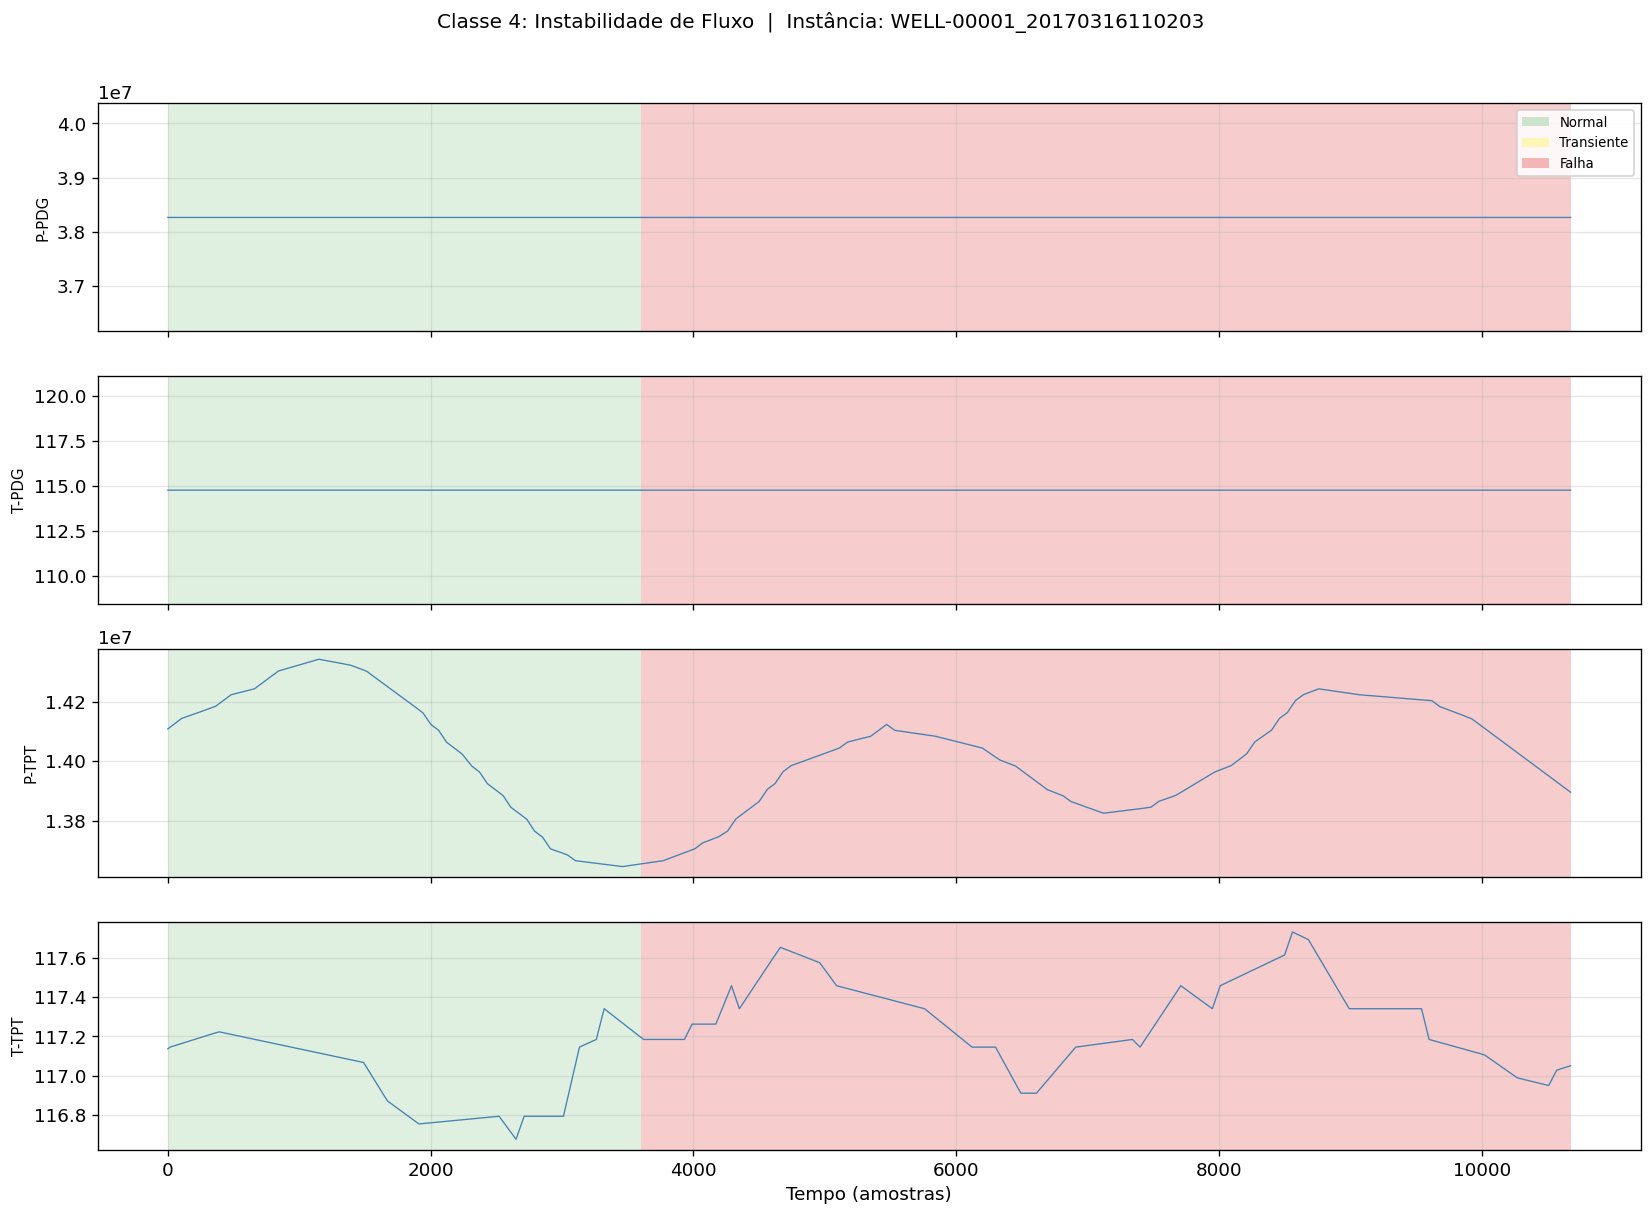

Figura salva: d:\Documentos\UnB\Projeto Final de Curso\TCC\notebooks\..\results\figures\serie_temporal_classe_5.png


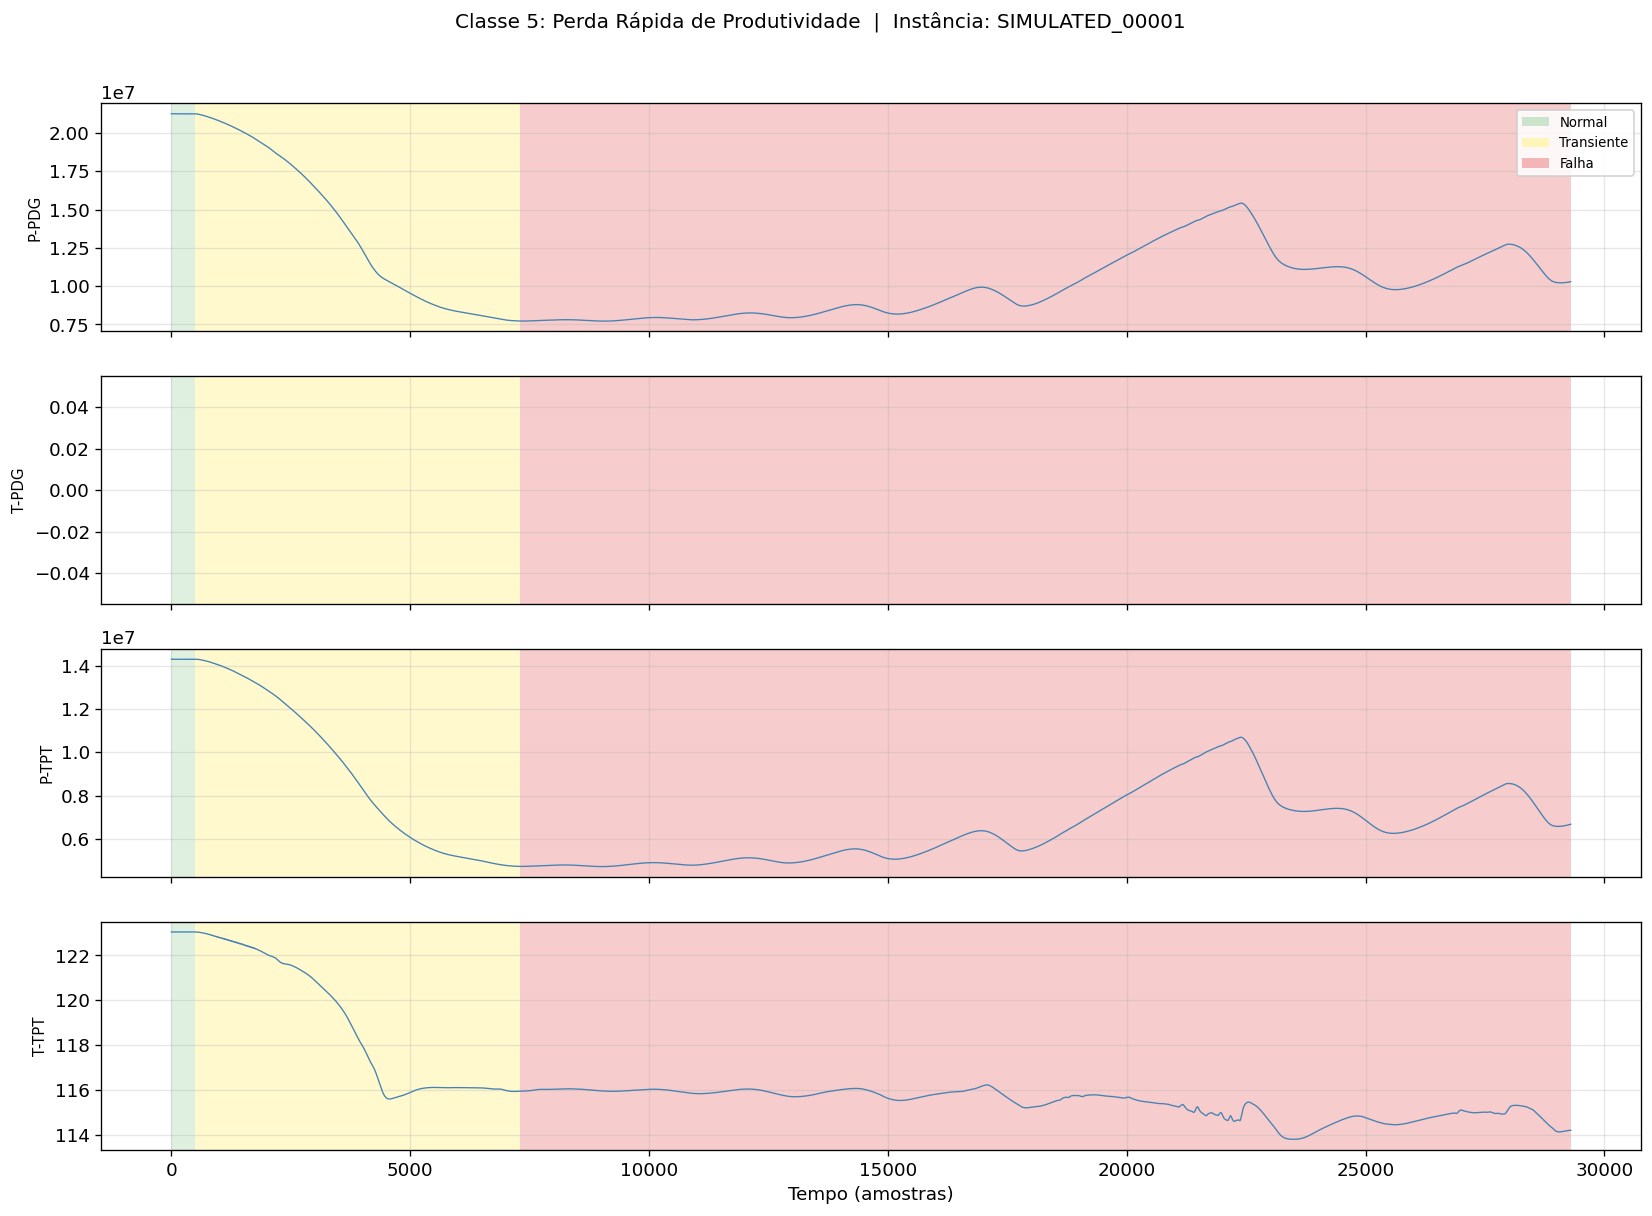

Figura salva: d:\Documentos\UnB\Projeto Final de Curso\TCC\notebooks\..\results\figures\serie_temporal_classe_6.png


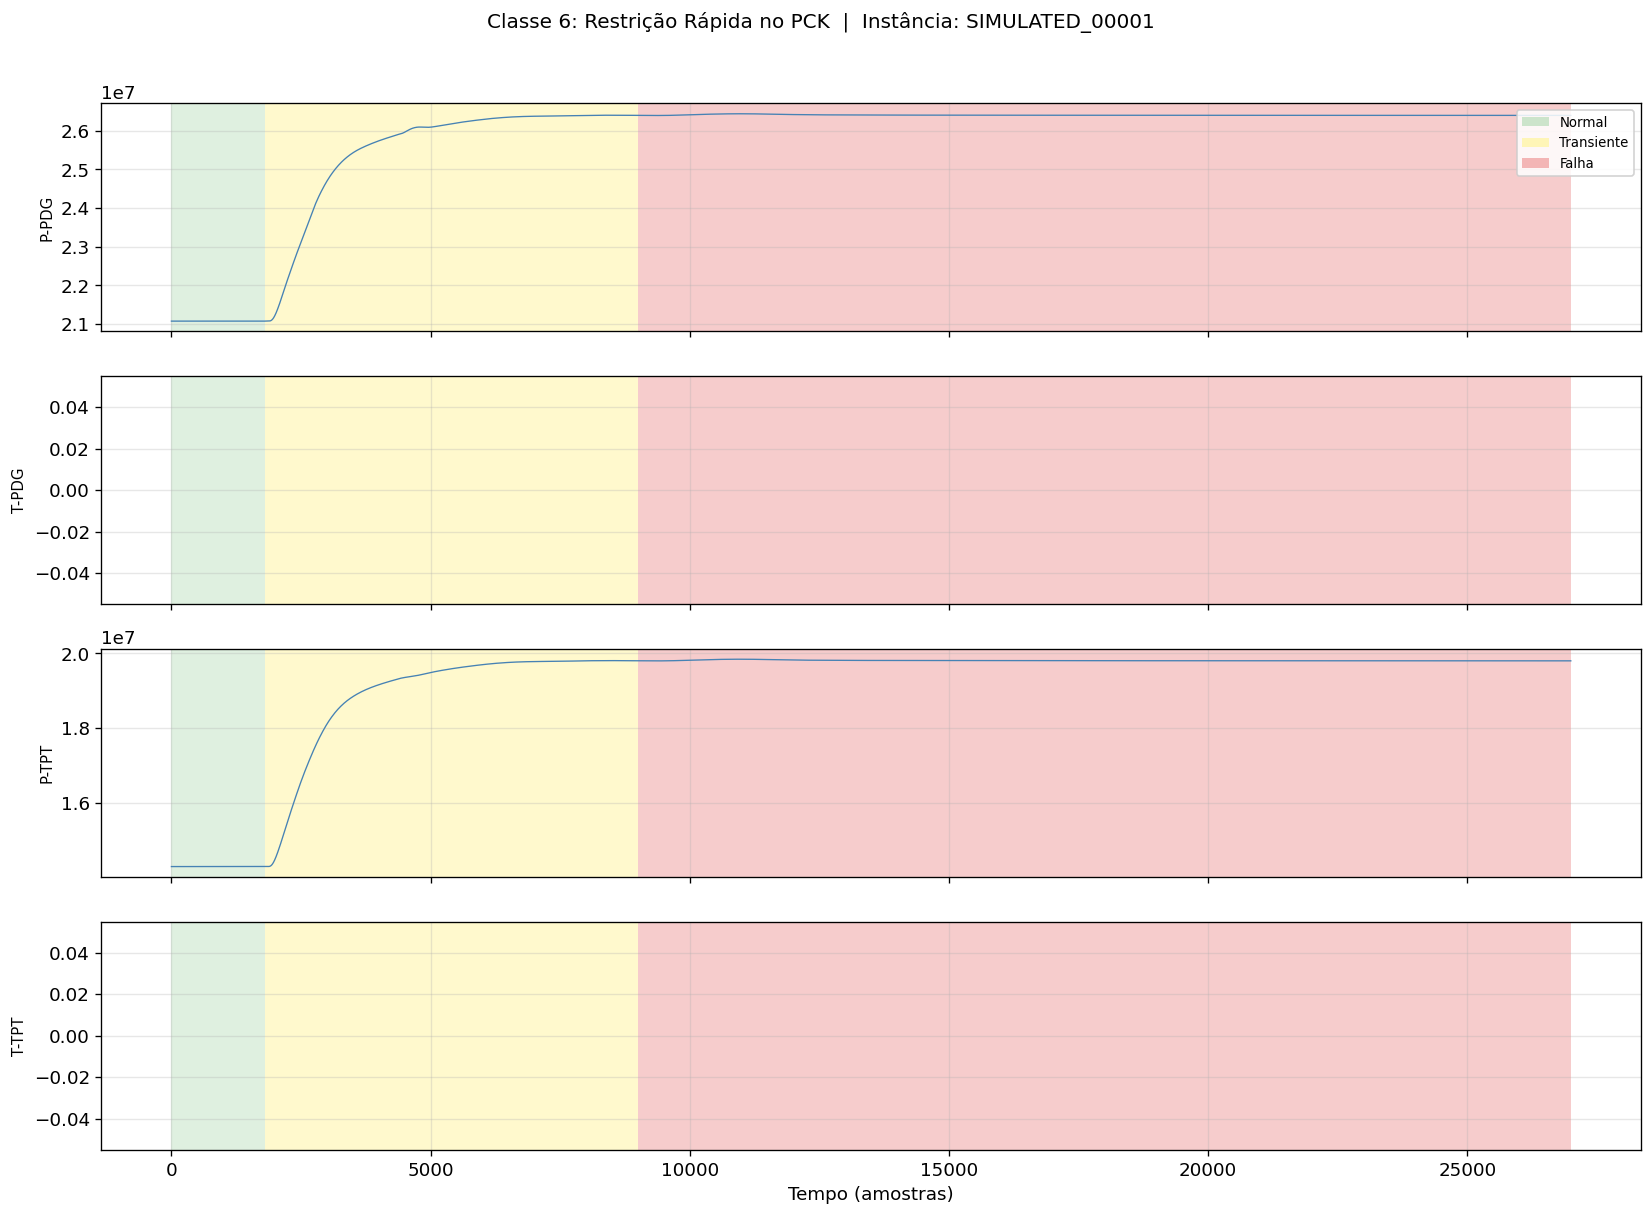

Figura salva: d:\Documentos\UnB\Projeto Final de Curso\TCC\notebooks\..\results\figures\serie_temporal_classe_7.png


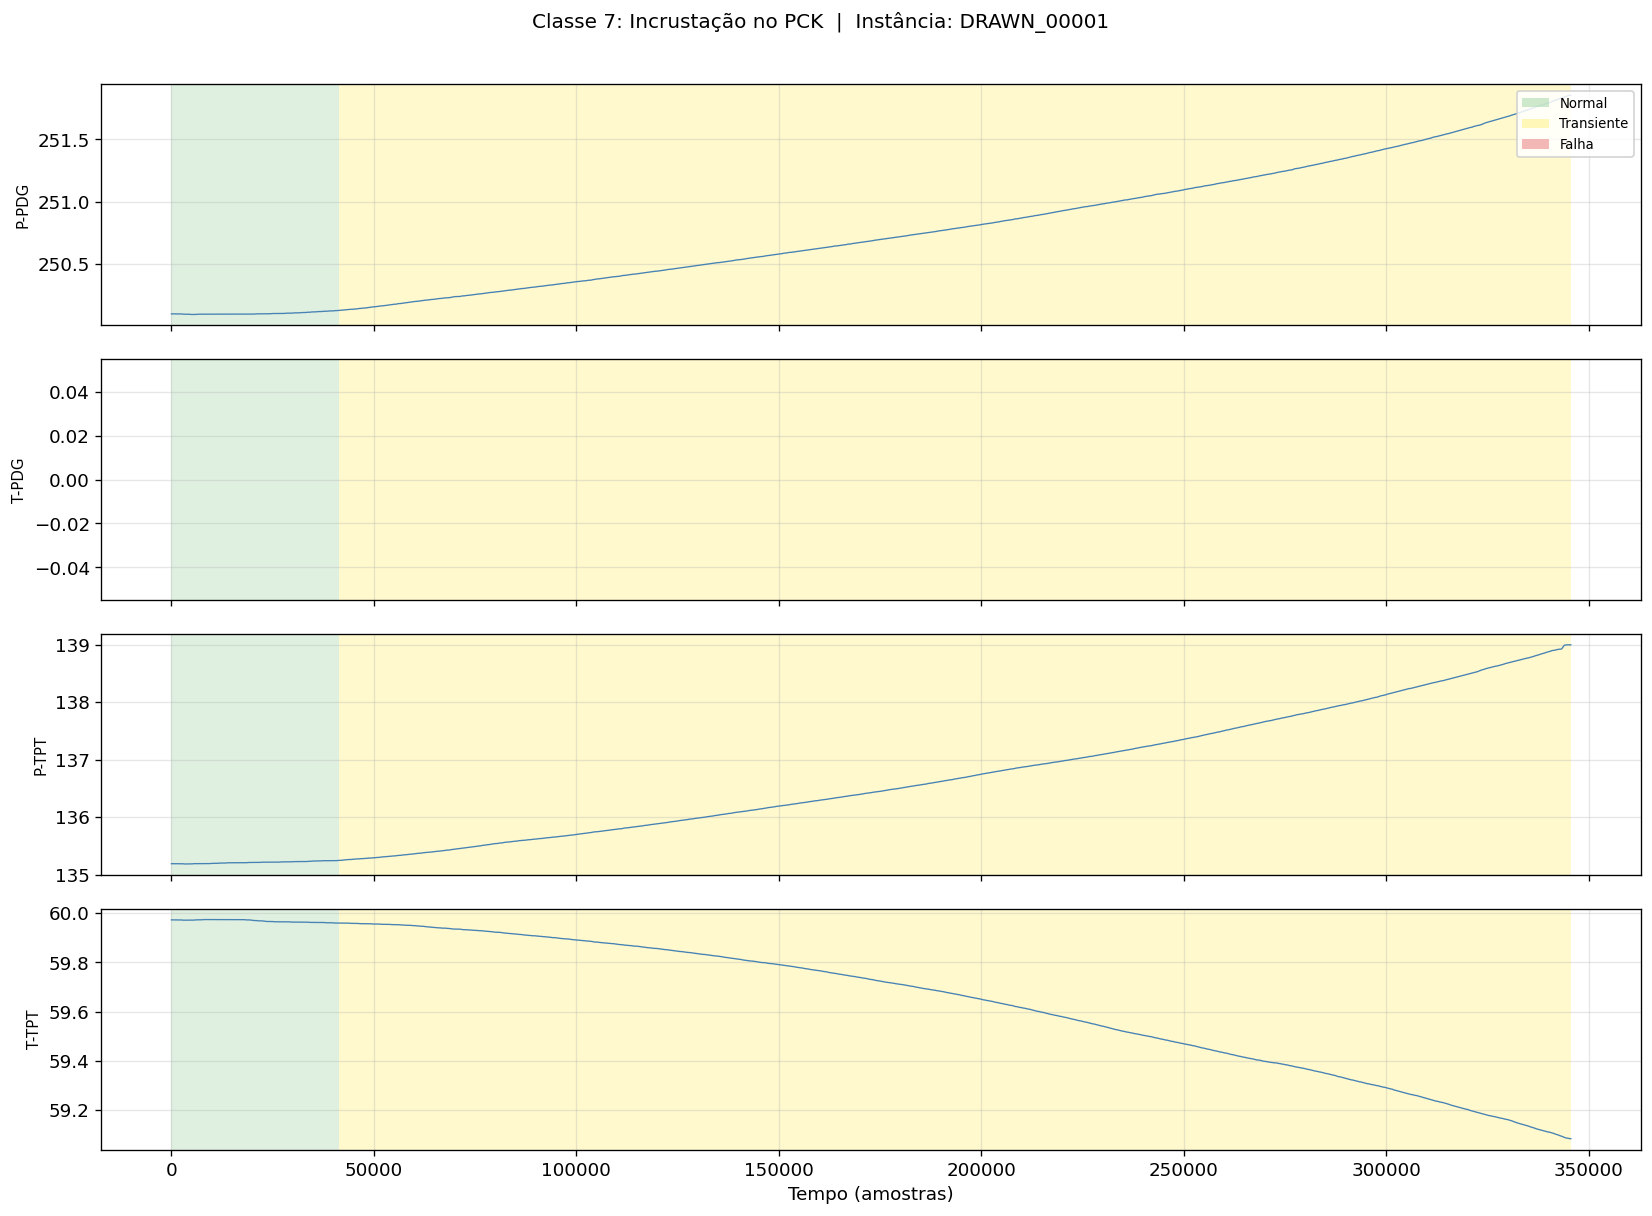

Figura salva: d:\Documentos\UnB\Projeto Final de Curso\TCC\notebooks\..\results\figures\serie_temporal_classe_8.png


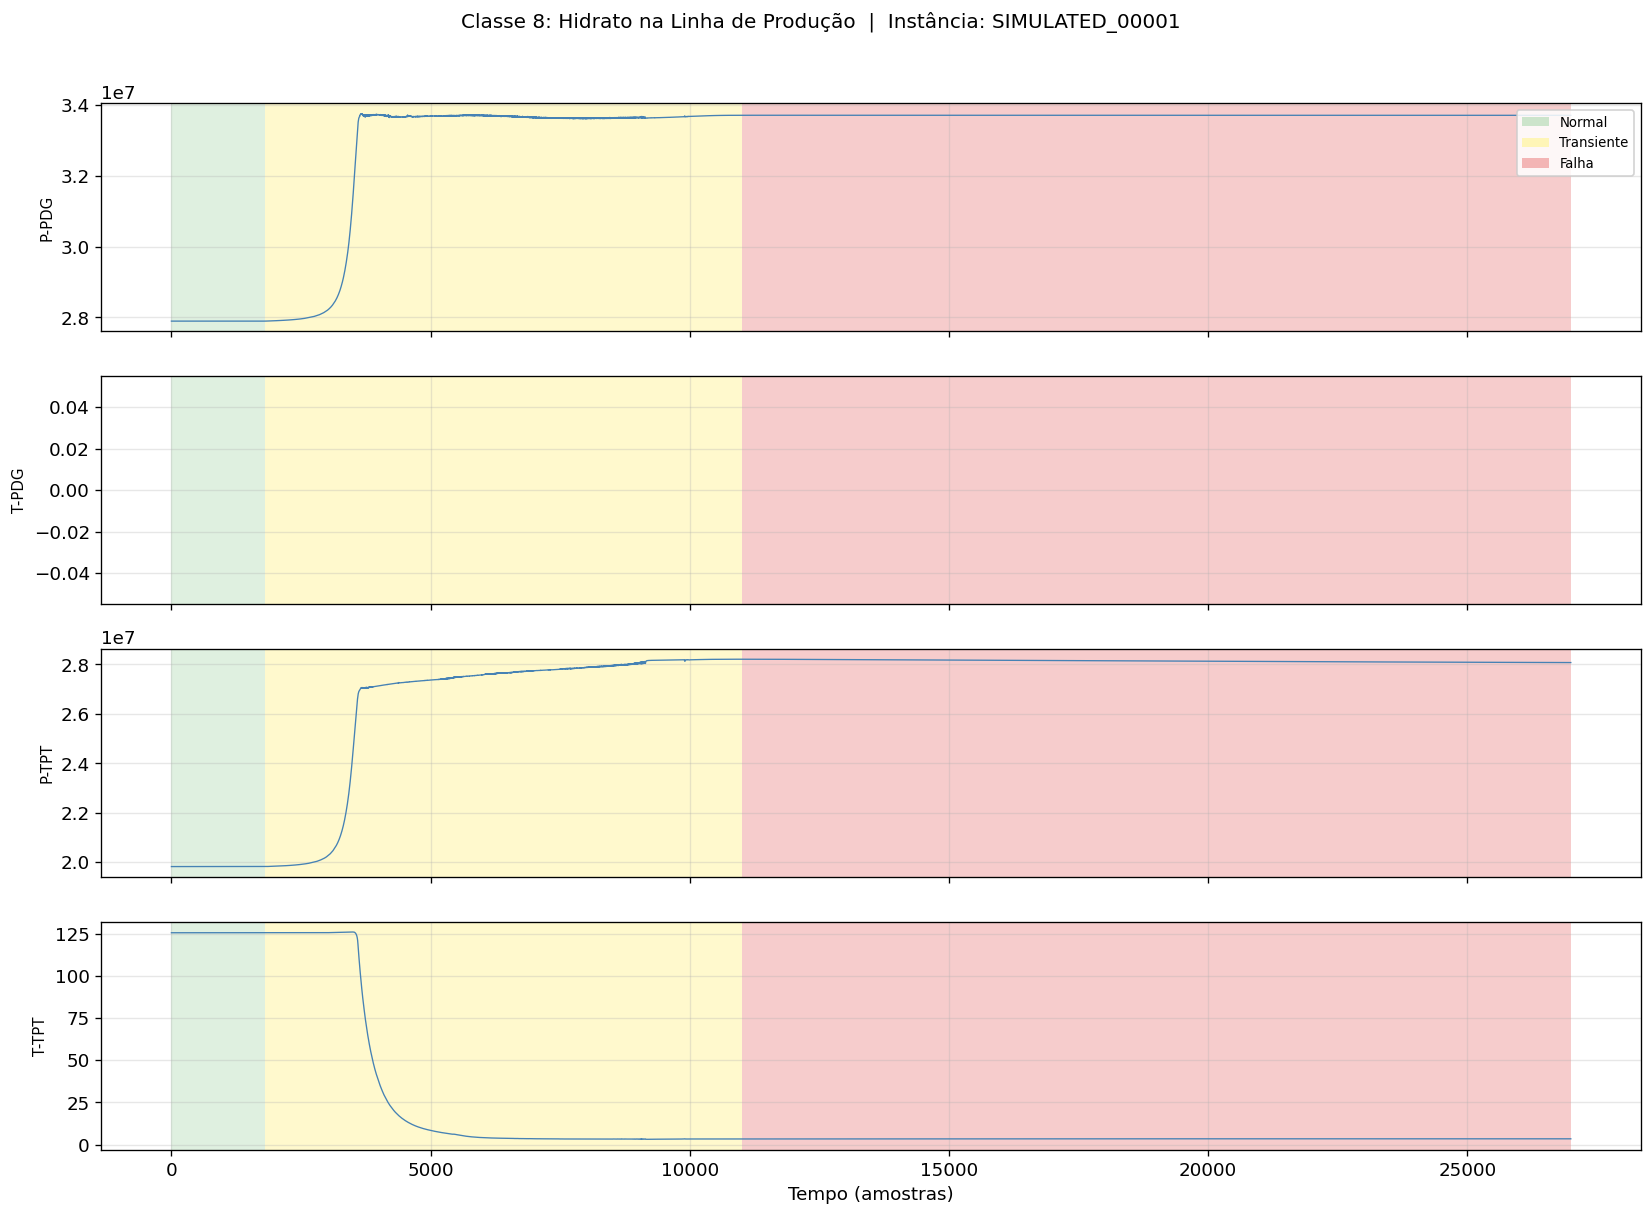

Figura salva: d:\Documentos\UnB\Projeto Final de Curso\TCC\notebooks\..\results\figures\serie_temporal_classe_9.png


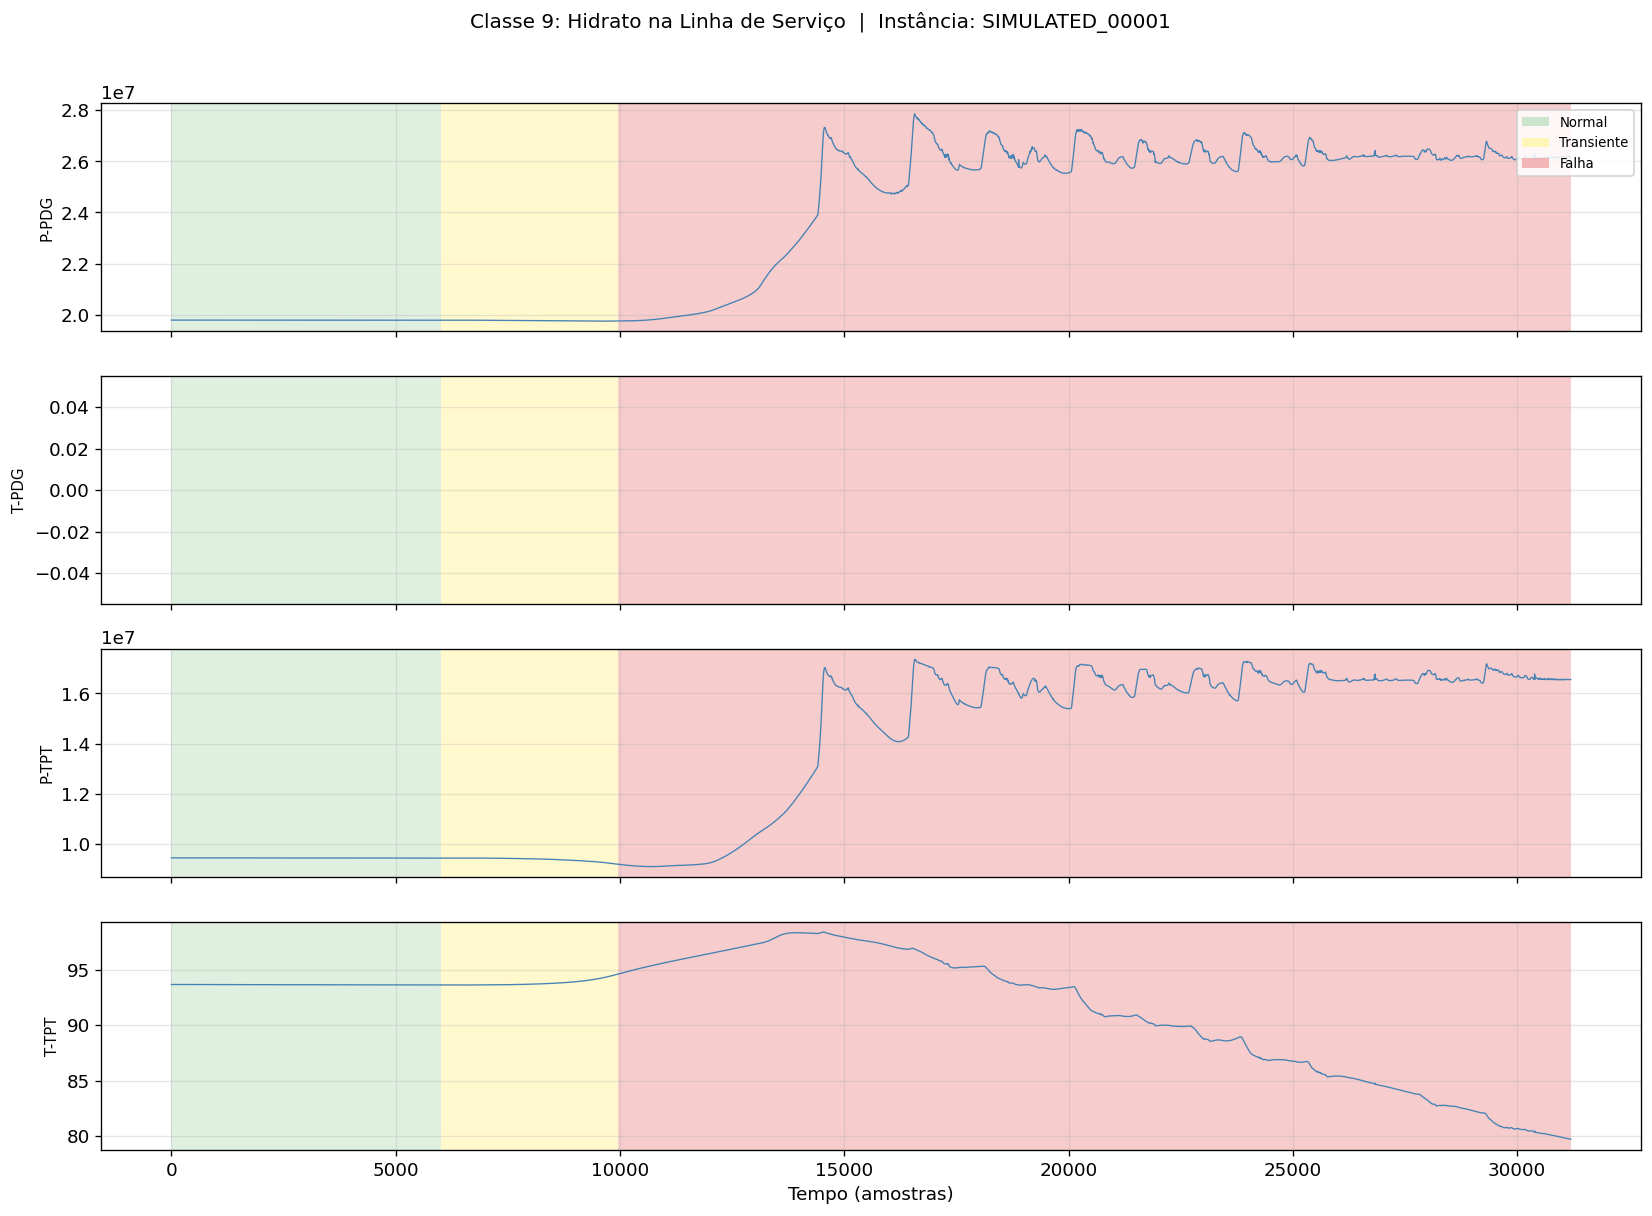

In [6]:
for fault_class, label in FAULT_CLASSES.items():
    df_class = df_sample[df_sample['fault_class'] == fault_class]
    if df_class.empty:
        continue
    first_instance = df_class['instance_id'].iloc[0]
    df_inst = df_class[df_class['instance_id'] == first_instance]
    sensors_available = [s for s in KEY_SENSORS if s in df_inst.columns]
    fig = plot_time_series(
        df_inst,
        sensors=sensors_available[:4],
        save_name=f'serie_temporal_classe_{fault_class}'
    )
    plt.show()

## 1.6 Correlação entre sensores

Figura salva: d:\Documentos\UnB\Projeto Final de Curso\TCC\notebooks\..\results\figures\correlacao_sensores.png


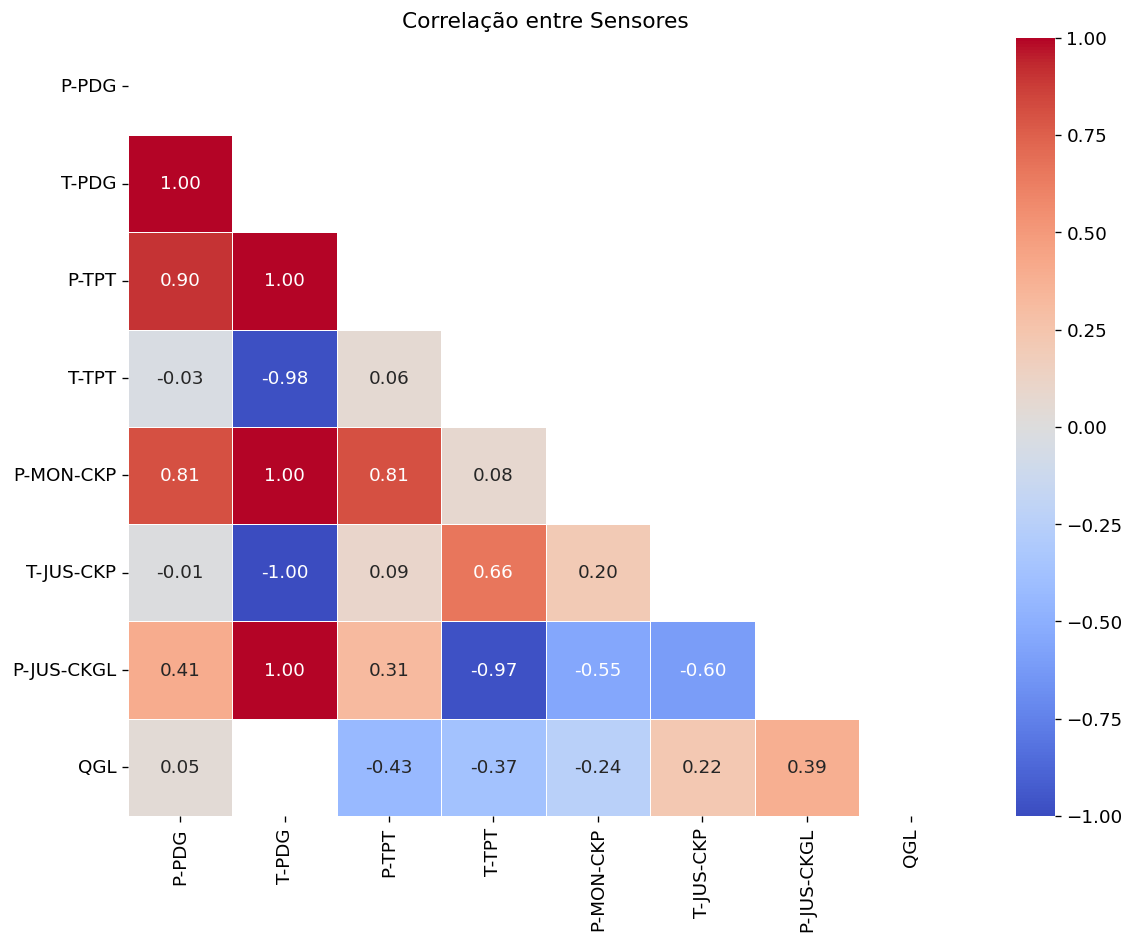

In [7]:
fig = plot_correlation_heatmap(df_sample)
plt.show()

## 1.7 Os Três Estados Operacionais

O 3W Dataset rotula cada segundo com um **estado operacional**:

| Código | Estado | Significado |
|--------|--------|------------|
| NaN / 0 | Normal | Poço operando sem anomalias |
| 101–109 | **Transiente** | Falha se desenvolvendo — janela para detecção precoce |
| 1–9 | **Ativo** | Falha instalada — confirmação do evento |

O pipeline de modelagem classifica janelas de 300 s nesses **17 estados** (o modelo não vê estado a estado, mas uma janela completa).
Detectar o **estado transiente** com antecedência é o objetivo operacional mais valioso — há tempo para intervenção antes da falha completa.

No exemplo abaixo, vemos como uma instância de DHSV evolui no tempo:

In [8]:
# Mostrar como uma instância evolui entre estados: Normal → Transiente → Ativo
from config import WINDOW_CLASSES

# Usar uma instância de DHSV (classe 2) — evento bem definido com transiente claro
df_inst = df_sample[df_sample['fault_class'] == 2].copy()
if not df_inst.empty:
    first_id = df_inst['instance_id'].iloc[0]
    df_inst = df_inst[df_inst['instance_id'] == first_id]

    n_nan    = df_inst['class'].isna().sum()
    n_trans  = (df_inst['class'] == 102).sum()  # transiente DHSV
    n_active = (df_inst['class'] == 2).sum()     # DHSV ativo

    total = len(df_inst)
    print(f'Instância: {first_id}  |  Total: {total:,} timesteps')
    print(f'\nProgressão dos estados operacionais:')
    print(f'  Normal (NaN)       : {n_nan:>6,} s  ({100*n_nan/total:.1f}%)')
    print(f'  Transiente DHSV (102): {n_trans:>6,} s  ({100*n_trans/total:.1f}%)')
    print(f'  DHSV Ativo (2)     : {n_active:>6,} s  ({100*n_active/total:.1f}%)')
    print(f'\nDesde o início do transiente até o final: {n_trans + n_active:,} s de anomalia detectável')
    print('→ Detectar o estado 102 (transiente) dá tempo de intervir antes da falha completa.')
else:
    print('Nenhuma instância de classe 2 na amostra carregada.')

Instância: SIMULATED_00001  |  Total: 28,799 timesteps

Progressão dos estados operacionais:
  Normal (NaN)       :      0 s  (0.0%)
  Transiente DHSV (102):  3,600 s  (12.5%)
  DHSV Ativo (2)     : 21,599 s  (75.0%)

Desde o início do transiente até o final: 25,199 s de anomalia detectável
→ Detectar o estado 102 (transiente) dá tempo de intervir antes da falha completa.


## 1.7 Conclusões da EDA

Com base na exploração acima:

**Classes com poucos exemplos (possível problema de desbalanceamento):**
- Classe 2 (DHSV): 38 instâncias — maior risco de subaprendizado pelo modelo
- Classe 7 (PCK Incrustação): 46 instâncias — detectada parcialmente mesmo pelo melhor modelo

**Sensores com mais dados faltantes:**
- `T-PDG`: ausente em ~94% das janelas (sensor de fundo inativado na maioria das instâncias)
- `P-JUS-CKGL` e `QGL`: alta taxa de NaN em poços sem gás lift ativo

**Classes visualmente similares (difíceis de separar):**
- Classes 3 (Golfadas) e 4 (Instabilidade de Fluxo): ambas geram oscilações em P-TPT
- Classes 8 e 9 (Hidratos): padrões de queda de pressão similares; diferem no subsistema afetado

**Sensores com maior variação durante falhas:**
- `P-TPT` (pressão na árvore de natal molhada): discrimina quase todos os eventos
- `T-TPT` (temperatura na árvore): especialmente informativo para eventos de hidrato
- `T-JUS-CKP` (temperatura a jusante do choke): sinal de obstrução no PCK

**Sobre os estados operacionais:**
Cada instância percorre três fases no tempo: **Normal → Transiente → Ativo**.
O transiente é a janela de oportunidade para detecção precoce — antes de a falha se instalar.
Na Etapa 3, cada janela de 300 s será rotulada com um dos 17 estados operacionais (Normal + 9 Ativos + 7 Transientes).